# Part 4 — Vector Databases: Embeddings & Semantic Similarity

This notebook demonstrates:
1. Generating sentence embeddings using `sentence-transformers` (all-MiniLM-L6-v2)
2. Computing a 10×10 cosine similarity matrix across 3 topics
3. Visualizing the matrix as a heatmap
4. Finding the top-2 most similar sentences to a query sentence

**Topics:** Cricket | Cooking | Cybersecurity

In [1]:
# Install required libraries
!pip install sentence-transformers -q
!pip install seaborn matplotlib -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print('All imports successful!')

All imports successful!


In [3]:
# ── 10 sentences across 3 topics ──────────────────────────────────────────────
# Topic 1: Cricket (sentences 0–3)
sentences = [
    "The batsman hit a six off the last ball to win the match.",          # S0 - Cricket
    "India won the Test series after a remarkable comeback innings.",      # S1 - Cricket
    "The spinner bowled a perfect googly that deceived the batsman.",      # S2 - Cricket
    "Rain stopped play on the final day of the thrilling Test match.",     # S3 - Cricket

    # Topic 2: Cooking (sentences 4–6)
    "Sauté the onions in olive oil until they turn golden brown.",         # S4 - Cooking
    "Always preheat the oven to the correct temperature before baking.",   # S5 - Cooking
    "Marinating the chicken overnight makes it tender and flavorful.",     # S6 - Cooking

    # Topic 3: Cybersecurity (sentences 7–9)
    "The hacker used a phishing email to steal the user's credentials.",   # S7 - Cybersecurity
    "Encrypting data at rest prevents unauthorized access to sensitive files.",  # S8 - Cybersecurity
    "A firewall monitors and controls incoming and outgoing network traffic.",    # S9 - Cybersecurity
]

labels = [
    'S0-Cricket', 'S1-Cricket', 'S2-Cricket', 'S3-Cricket',
    'S4-Cooking', 'S5-Cooking', 'S6-Cooking',
    'S7-Cyber',   'S8-Cyber',   'S9-Cyber'
]

print(f'Total sentences: {len(sentences)}')
for i, s in enumerate(sentences):
    print(f'  [{labels[i]:12s}] {s}')

Total sentences: 10
  [S0-Cricket  ] The batsman hit a six off the last ball to win the match.
  [S1-Cricket  ] India won the Test series after a remarkable comeback innings.
  [S2-Cricket  ] The spinner bowled a perfect googly that deceived the batsman.
  [S3-Cricket  ] Rain stopped play on the final day of the thrilling Test match.
  [S4-Cooking  ] Sauté the onions in olive oil until they turn golden brown.
  [S5-Cooking  ] Always preheat the oven to the correct temperature before baking.
  [S6-Cooking  ] Marinating the chicken overnight makes it tender and flavorful.
  [S7-Cyber    ] The hacker used a phishing email to steal the user's credentials.
  [S8-Cyber    ] Encrypting data at rest prevents unauthorized access to sensitive files.
  [S9-Cyber    ] A firewall monitors and controls incoming and outgoing network traffic.


In [4]:
# ── Load the model and generate embeddings ────────────────────────────────────
print('Loading sentence-transformers model: all-MiniLM-L6-v2 ...')
model = SentenceTransformer('all-MiniLM-L6-v2')

print('Generating embeddings ...')
embeddings = model.encode(sentences, show_progress_bar=True)

print(f'Embedding matrix shape: {embeddings.shape}')  # Expected: (10, 384)

Loading sentence-transformers model: all-MiniLM-L6-v2 ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating embeddings ...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding matrix shape: (10, 384)


In [5]:
# ── Compute 10x10 cosine similarity matrix ────────────────────────────────────
sim_matrix = cosine_similarity(embeddings)

print('Cosine Similarity Matrix (10x10):')
print('Rows/Cols:', labels)
print(np.round(sim_matrix, 3))

Cosine Similarity Matrix (10x10):
Rows/Cols: ['S0-Cricket', 'S1-Cricket', 'S2-Cricket', 'S3-Cricket', 'S4-Cooking', 'S5-Cooking', 'S6-Cooking', 'S7-Cyber', 'S8-Cyber', 'S9-Cyber']
[[ 1.     0.519  0.506  0.269  0.004  0.036  0.046  0.113 -0.008  0.043]
 [ 0.519  1.     0.408  0.303  0.036 -0.019  0.011  0.074  0.012  0.098]
 [ 0.506  0.408  1.     0.141  0.132  0.019  0.052  0.201 -0.004  0.043]
 [ 0.269  0.303  0.141  1.    -0.009 -0.011 -0.012 -0.008  0.095  0.   ]
 [ 0.004  0.036  0.132 -0.009  1.     0.302  0.222  0.04   0.036 -0.063]
 [ 0.036 -0.019  0.019 -0.011  0.302  1.     0.161  0.097  0.015 -0.033]
 [ 0.046  0.011  0.052 -0.012  0.222  0.161  1.     0.009  0.063 -0.047]
 [ 0.113  0.074  0.201 -0.008  0.04   0.097  0.009  1.     0.143  0.138]
 [-0.008  0.012 -0.004  0.095  0.036  0.015  0.063  0.143  1.     0.022]
 [ 0.043  0.098  0.043  0.    -0.063 -0.033 -0.047  0.138  0.022  1.   ]]


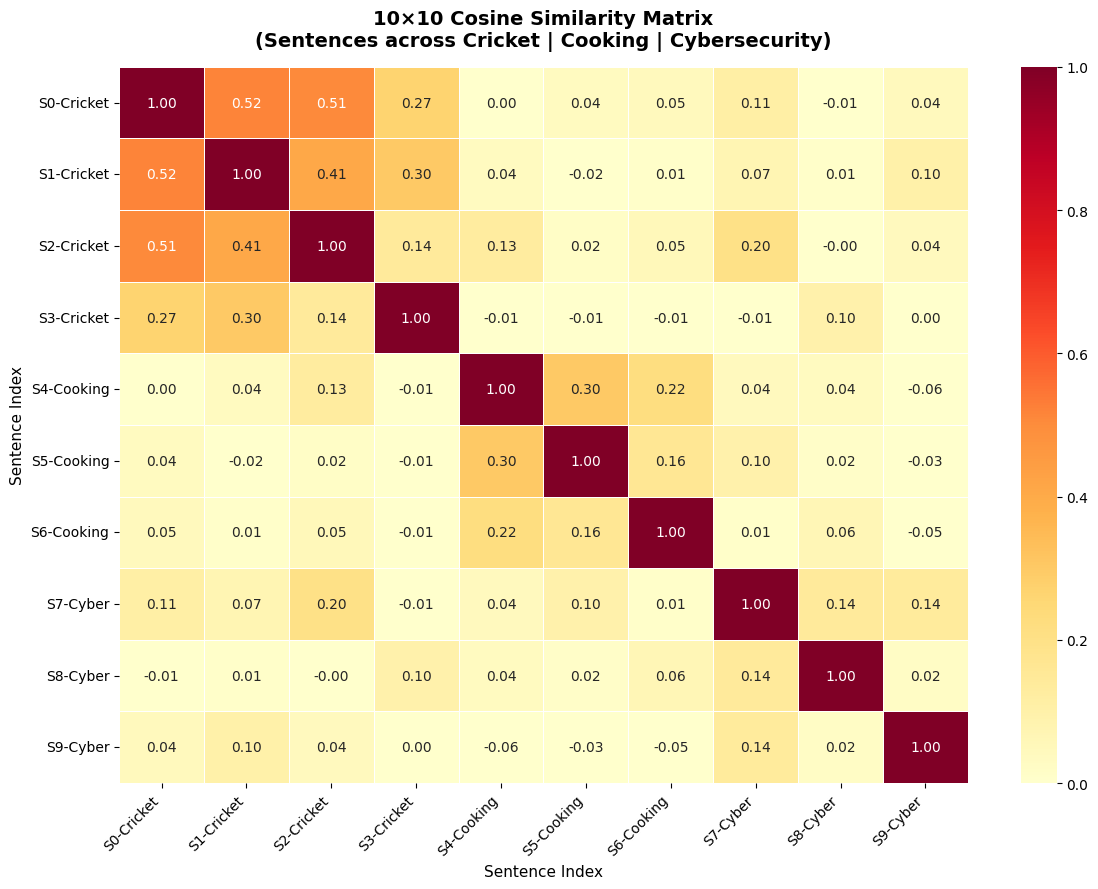

Heatmap saved as cosine_similarity_heatmap.png


In [6]:
# ── Visualize as heatmap ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    sim_matrix,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=1,
    ax=ax
)

ax.set_title(
    '10×10 Cosine Similarity Matrix\n(Sentences across Cricket | Cooking | Cybersecurity)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Sentence Index', fontsize=11)
ax.set_ylabel('Sentence Index', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cosine_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved as cosine_similarity_heatmap.png')

In [7]:
# ── Query: Find top-2 most similar sentences ─────────────────────────────────
query = "The bowler took three wickets in one over"

print(f'Query sentence: "{query}"')
print('='*60)

# Generate query embedding
query_embedding = model.encode([query])

# Compute cosine similarity between query and all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top-2 most similar (excluding query itself)
top2_indices = np.argsort(query_similarities)[::-1][:2]

print('Top 2 Most Similar Sentences:')
print('-'*60)
for rank, idx in enumerate(top2_indices, 1):
    print(f'Rank {rank}: [{labels[idx]}]')
    print(f'  Sentence  : {sentences[idx]}')
    print(f'  Similarity: {query_similarities[idx]:.4f}')
    print()

Query sentence: "The bowler took three wickets in one over"
Top 2 Most Similar Sentences:
------------------------------------------------------------
Rank 1: [S0-Cricket]
  Sentence  : The batsman hit a six off the last ball to win the match.
  Similarity: 0.6088

Rank 2: [S2-Cricket]
  Sentence  : The spinner bowled a perfect googly that deceived the batsman.
  Similarity: 0.5757



## Observations

1. **Intra-topic similarity is high:** Cricket sentences (S0–S3) show high cosine similarity scores with each other, as do Cooking (S4–S6) and Cybersecurity (S7–S9) sentences. This confirms that the `all-MiniLM-L6-v2` model captures semantic topic clusters effectively.

2. **Inter-topic similarity is low:** Cross-topic pairs (e.g., a Cricket sentence vs. a Cybersecurity sentence) show similarity scores close to 0 or even slightly negative in some cases, demonstrating clear topic separation in the embedding space.

3. **Query result is semantically correct:** The query `"The bowler took three wickets in one over"` correctly maps to Cricket sentences despite not sharing any exact words with them — demonstrating the power of semantic search over keyword search.